# 2. Race & Ethnicity Change (2010–2020)

In [1]:
%run 00_shared.py

## Raw peek

In [2]:
xl_race = pd.ExcelFile(f"{DATA_RAW}/Counties race x ethn change 2010 to 2020.xlsx")
print("Sheets:", xl_race.sheet_names)

Sheets: ['Sheet1', 'Change']


In [3]:
race = xl_race.parse(xl_race.sheet_names[0])
print(f"Shape: {race.shape}")
race.head(10)

Shape: (35, 20)


,2020,Total:,Population of one race:,White alone,Black or African American alone,American Indian and Alaska Native alone,Asian alone,Native Hawaiian and Other Pacific Islander alone,Some Other Race alone,Population of two or more races:,Hispanic or Latino,Not Hispanic or Latino:,Not Hispanic or Latino: Population of one race:,Not Hispanic or Latino: White alone,Not Hispanic or Latino: Black or African American alone,Not Hispanic or Latino: American Indian and Alaska Native alone,Not Hispanic or Latino: Asian alone,Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone,Not Hispanic or Latino: Some Other Race alone,Not Hispanic or Latino: Population of two or more races:
0,Androscoggin County,111139,105370,96625,6531,420,906,58,830,5769,2222,108917,104014,95875,6436,382,895,50,376,4903
1,Aroostook County,67105,64900,62521,447,1221,396,21,294,2205,912,66193,64333,62163,423,1206,392,18,131,1860
2,Cumberland County,303069,287623,264408,12120,831,7204,98,2962,15446,8011,295058,283161,262137,11925,667,7167,96,1169,11897
3,Franklin County,29456,28195,27356,174,73,386,24,182,1261,407,29049,27965,27211,166,73,383,23,109,1084
4,Hancock County,55478,53030,51444,355,262,566,10,393,2448,969,54509,52469,51098,351,231,560,10,219,2040
5,Kennebec County,123642,117175,113639,919,511,1227,29,850,6467,2552,121090,115621,112682,850,460,1215,29,385,5469
6,Knox County,40607,38683,37713,272,154,250,18,276,1924,672,39935,38340,37533,256,139,250,18,144,1595
7,Lincoln County,35237,33869,33215,165,105,234,9,141,1368,395,34842,33665,33071,156,105,227,9,97,1177
8,Oxford County,57777,54826,53795,229,197,275,18,312,2951,865,56912,54300,53456,209,187,275,16,157,2612
9,Penobscot County,152199,145061,139311,1507,1431,1865,46,901,7138,2715,149484,143408,138306,1443,1349,1853,37,420,6076


In [4]:
print(race.dtypes)
print("\nNulls per column:")
print(race.isnull().sum())

2020                                                                        object
Total:                                                                      object
Population of one race:                                                     object
White alone                                                                 object
Black or African American alone                                             object
American Indian and Alaska Native alone                                     object
Asian alone                                                                 object
Native Hawaiian and Other Pacific Islander alone                            object
Some Other Race alone                                                       object
Population of two or more races:                                            object
Hispanic or Latino                                                          object
Not Hispanic or Latino:                                                     object
Not 

In [5]:
race.describe(include="all")

,2020,Total:,Population of one race:,White alone,Black or African American alone,American Indian and Alaska Native alone,Asian alone,Native Hawaiian and Other Pacific Islander alone,Some Other Race alone,Population of two or more races:,Hispanic or Latino,Not Hispanic or Latino:,Not Hispanic or Latino: Population of one race:,Not Hispanic or Latino: White alone,Not Hispanic or Latino: Black or African American alone,Not Hispanic or Latino: American Indian and Alaska Native alone,Not Hispanic or Latino: Asian alone,Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone,Not Hispanic or Latino: Some Other Race alone,Not Hispanic or Latino: Population of two or more races:
count,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33,33
unique,17,33,33,33,33,32,33,25,31,33,32,33,33,33,32,33,33,24,32,33
top,Androscoggin County,111139,105370,96625,6531,113,906,10,77,5769,667,108917,104014,95875,156,382,895,5,14,4903
freq,2,1,1,1,1,2,1,3,2,1,2,1,1,1,2,1,1,3,2,1


In [6]:
if len(xl_race.sheet_names) > 1:
    for sheet in xl_race.sheet_names[1:]:
        df = xl_race.parse(sheet)
        print(f"\n--- Sheet: {sheet} | Shape: {df.shape} ---")
        display(df.head(5))


--- Sheet: Change | Shape: (35, 12) ---


,Unnamed: 0,Total:,Hispanic or Latino,Not Hispanic or Latino:,Population of one race:,White alone NH,Black or African American alone NH,American Indian and Alaska Native alone NH,Asian alone NH,Native Hawaiian and Other Pacific Islander alone NH,Some Other Race alone NH,Population of two or more races: NH
0,Androscoggin County,NaN,553,2884,-61,-3056,2578,-1,122,21,275,2945
1,Aroostook County,NaN,245,-5010,-5968,-6178,-7,11,82,7,117,958
2,Cumberland County,NaN,2966,18429,11183,3669,5348,-152,1462,16,840,7246
3,Franklin County,NaN,92,-1404,-2103,-2520,96,-40,254,13,94,699
4,Hancock County,NaN,375,685,-786,-1255,145,32,115,4,173,1471


## 2a. Clean Race Data (2020 County Snapshot)

In [7]:
raw_2020 = xl_race.parse("Sheet1").iloc[:16].copy()

col_rename = {
    raw_2020.columns[0]:  "County",
    raw_2020.columns[1]:  "Total",
    raw_2020.columns[2]:  "One_Race",
    raw_2020.columns[3]:  "White",
    raw_2020.columns[4]:  "Black",
    raw_2020.columns[5]:  "AIAN",
    raw_2020.columns[6]:  "Asian",
    raw_2020.columns[7]:  "NHOPI",
    raw_2020.columns[8]:  "Other_Race",
    raw_2020.columns[9]:  "Two_Plus",
    raw_2020.columns[10]: "Hispanic",
    raw_2020.columns[11]: "NH_Total",
    raw_2020.columns[12]: "NH_One_Race",
    raw_2020.columns[13]: "NH_White",
    raw_2020.columns[14]: "NH_Black",
    raw_2020.columns[15]: "NH_AIAN",
    raw_2020.columns[16]: "NH_Asian",
    raw_2020.columns[17]: "NH_NHOPI",
    raw_2020.columns[18]: "NH_Other_Race",
    raw_2020.columns[19]: "NH_Two_Plus",
}
race_2020 = raw_2020.rename(columns=col_rename)

num_cols = [c for c in race_2020.columns if c != "County"]
race_2020[num_cols] = race_2020[num_cols].apply(pd.to_numeric, errors="coerce")
race_2020["County_Short"] = race_2020["County"].str.replace(" County", "", regex=False)

race_2020[["County", "Total", "White", "Black", "AIAN", "Asian", "Hispanic", "Two_Plus"]].set_index("County")

,Total,White,Black,AIAN,Asian,Hispanic,Two_Plus
County,,,,,,,
Androscoggin County,111139,96625,6531,420,906,2222,5769
Aroostook County,67105,62521,447,1221,396,912,2205
Cumberland County,303069,264408,12120,831,7204,8011,15446
Franklin County,29456,27356,174,73,386,407,1261
Hancock County,55478,51444,355,262,566,969,2448
Kennebec County,123642,113639,919,511,1227,2552,6467
Knox County,40607,37713,272,154,250,672,1924
Lincoln County,35237,33215,165,105,234,395,1368
Oxford County,57777,53795,229,197,275,865,2951


## 2b. Diversity Summary by County

In [8]:
diversity = race_2020[["County_Short", "Total"]].copy()
diversity["pct_white"]    = race_2020["NH_White"]   / race_2020["Total"] * 100
diversity["pct_black"]    = race_2020["NH_Black"]   / race_2020["Total"] * 100
diversity["pct_aian"]     = race_2020["NH_AIAN"]    / race_2020["Total"] * 100
diversity["pct_asian"]    = race_2020["NH_Asian"]   / race_2020["Total"] * 100
diversity["pct_hispanic"] = race_2020["Hispanic"]   / race_2020["Total"] * 100
diversity["pct_two_plus"] = race_2020["NH_Two_Plus"] / race_2020["Total"] * 100
diversity["pct_other"]    = (100 - diversity[["pct_white","pct_black","pct_aian",
                                               "pct_asian","pct_hispanic","pct_two_plus"]].sum(axis=1))
diversity["pct_nonwhite"] = 100 - diversity["pct_white"]

display(diversity.sort_values("pct_nonwhite", ascending=False)
        [["County_Short","Total","pct_nonwhite","pct_hispanic","pct_black","pct_aian","pct_asian","pct_two_plus"]]
        .rename(columns={"County_Short":"County","pct_nonwhite":"% Non-White","pct_hispanic":"% Hispanic",
                         "pct_black":"% Black","pct_aian":"% AIAN","pct_asian":"% Asian","pct_two_plus":"% 2+ Races"})
        .reset_index(drop=True))

print(f"\nMaine statewide NH-White: {race_2020['NH_White'].sum()/race_2020['Total'].sum()*100:.1f}%")

,County,Total,% Non-White,% Hispanic,% Black,% AIAN,% Asian,% 2+ Races
0,Androscoggin,111139,13.7,2.0,5.8,0.3,0.8,4.4
1,Cumberland,303069,13.5,2.6,3.9,0.2,2.4,3.9
2,Washington,31095,11.3,2.1,0.5,4.4,0.4,3.5
3,Penobscot,152199,9.1,1.8,0.9,0.9,1.2,4.0
4,Kennebec,123642,8.9,2.1,0.7,0.4,1.0,4.4
5,York,211972,8.5,1.9,0.9,0.3,1.2,3.8
6,Hancock,55478,7.9,1.7,0.6,0.4,1.0,3.7
7,Piscataquis,16800,7.9,1.6,0.3,0.6,0.7,4.2
8,Sagadahoc,36699,7.8,1.8,0.8,0.3,0.7,4.0
9,Franklin,29456,7.6,1.4,0.6,0.2,1.3,3.7



Maine statewide NH-White: 90.2%


## 2c. Racial Composition Stacked Bar by County

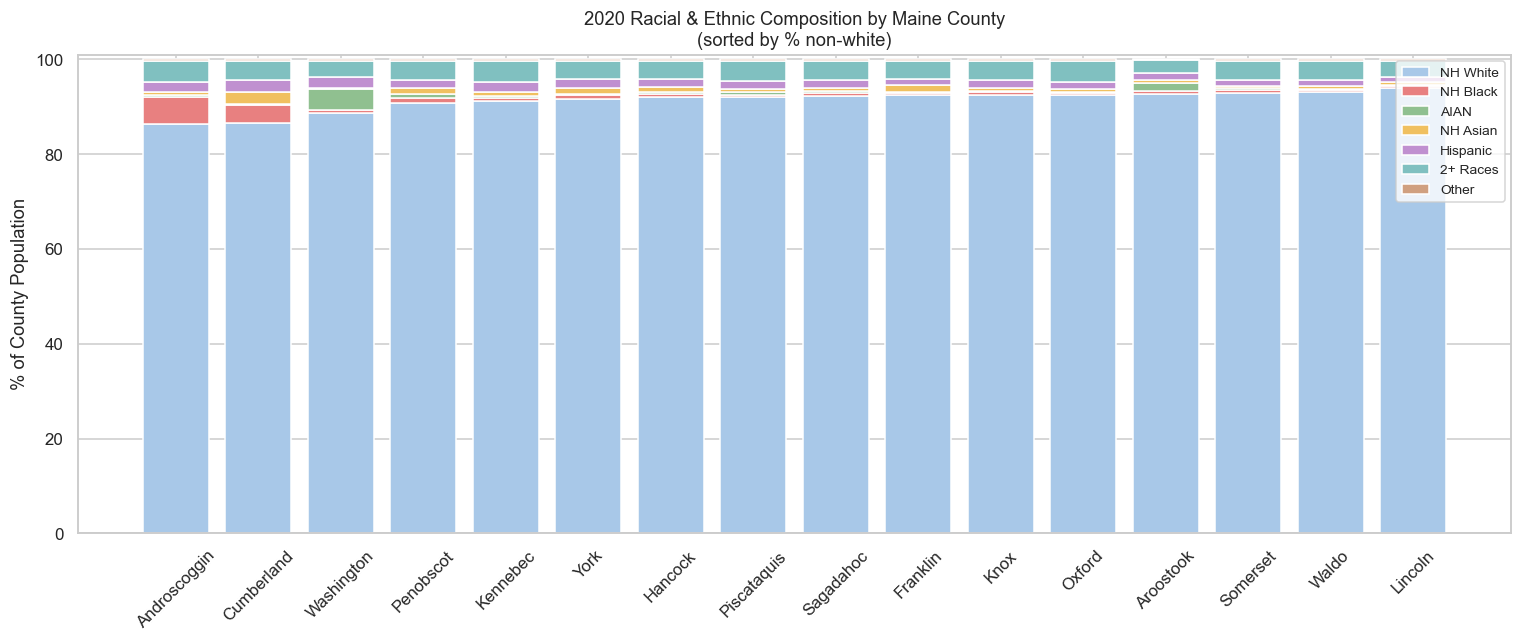

In [9]:
plot_d = diversity.sort_values("pct_nonwhite", ascending=False).set_index("County_Short")

stack_cols = {
    "NH White":  "pct_white",
    "NH Black":  "pct_black",
    "AIAN":      "pct_aian",
    "NH Asian":  "pct_asian",
    "Hispanic":  "pct_hispanic",
    "2+ Races":  "pct_two_plus",
    "Other":     "pct_other",
}
palette = ["#a8c8e8", "#e88080", "#90c090", "#f0c060", "#c090d0", "#80c0c0", "#d0a080"]

fig, ax = plt.subplots(figsize=(14, 6))
bottom = pd.Series(0.0, index=plot_d.index)
for (label, col), color in zip(stack_cols.items(), palette):
    vals = plot_d[col].clip(lower=0)
    ax.bar(plot_d.index, vals, bottom=bottom, label=label, color=color)
    bottom += vals

ax.set_ylabel("% of County Population")
ax.set_ylim(0, 101)
ax.set_title("2020 Racial & Ethnic Composition by Maine County\n(sorted by % non-white)")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 2d. Demographic Change 2010–2020 by County

Statewide 2010–2020 change by group:
Total            0.0
White      -26,033.0
Black        9,961.0
AIAN          -917.0
Asian        3,226.0
Hispanic     9,674.0
Two_Plus    34,577.0


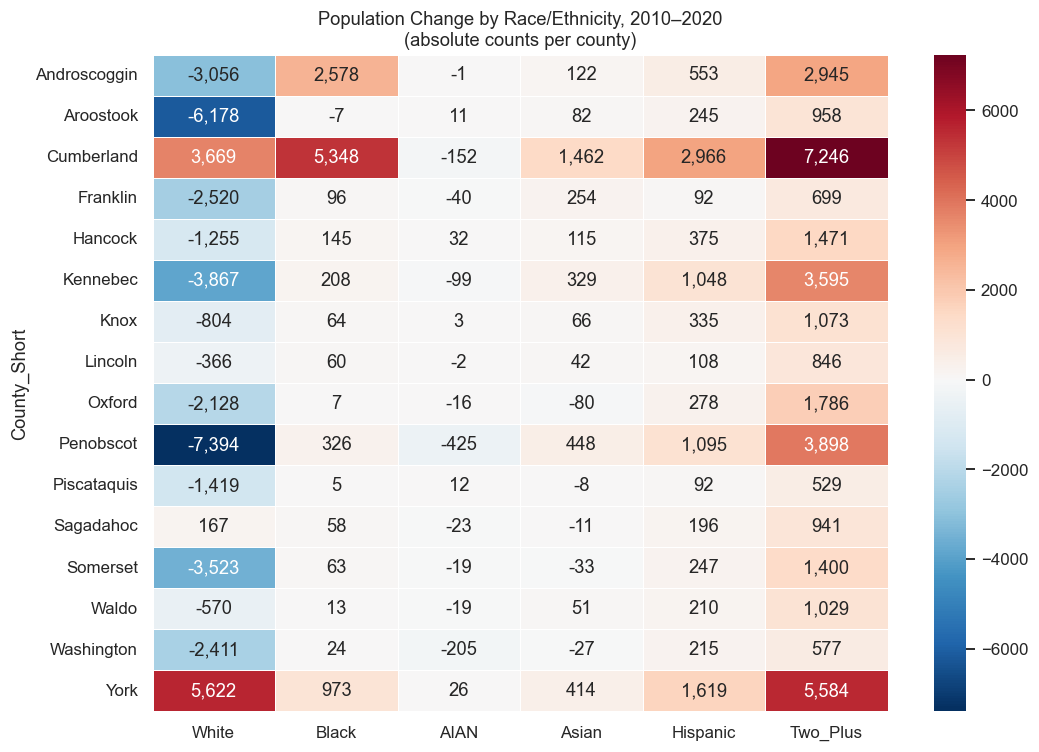

In [10]:
raw_chg = xl_race.parse("Change").iloc[:16].copy()

chg_rename = {
    raw_chg.columns[0]:  "County",
    raw_chg.columns[1]:  "Total",
    raw_chg.columns[2]:  "Hispanic",
    raw_chg.columns[3]:  "NH_Total",
    raw_chg.columns[4]:  "One_Race",
    raw_chg.columns[5]:  "White",
    raw_chg.columns[6]:  "Black",
    raw_chg.columns[7]:  "AIAN",
    raw_chg.columns[8]:  "Asian",
    raw_chg.columns[9]:  "NHOPI",
    raw_chg.columns[10]: "Other_Race",
    raw_chg.columns[11]: "Two_Plus",
}
chg = raw_chg.rename(columns=chg_rename)
num_cols_chg = [c for c in chg.columns if c != "County"]
chg[num_cols_chg] = chg[num_cols_chg].apply(pd.to_numeric, errors="coerce")
chg["County_Short"] = chg["County"].str.replace(" County", "", regex=False)

totals = chg[num_cols_chg].sum()
print("Statewide 2010\u20132020 change by group:")
print(totals[["Total","White","Black","AIAN","Asian","Hispanic","Two_Plus"]].to_string())

heat_cols = ["White", "Black", "AIAN", "Asian", "Hispanic", "Two_Plus"]
heat_data = chg.set_index("County_Short")[heat_cols]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heat_data, annot=True, fmt=",d", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_title("Population Change by Race/Ethnicity, 2010\u20132020\n(absolute counts per county)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Save

In [11]:
pd.to_pickle(
    {"race_2020": race_2020, "diversity": diversity, "chg": chg},
    f"{DATA_PROCESSED}/race_ethnicity.pkl"
)
print("Saved race_ethnicity.pkl")

Saved race_ethnicity.pkl
